# Part A: Conditional VAE on CIFAR10

**Abstract**

This notebook builds and evaluates a baseline Conditional Variational Autoencoder (CVAE) for class-conditional image generation on the CIFAR10 dataset. The model is trained to reconstruct and generate 32x32 color images across all 10 classes, conditioned on class label, and is evaluated through reconstruction error, latent space structure, and the quality of 1000 generated images (100 per class) using both manual eye-test scoring and Frechet Inception Distance (FID). This baseline establishes a reference point for the systematic experiments and improvements carried out in `vae_improvement.ipynb`.


## 1. Imports and Setup


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
from torchvision.datasets import CIFAR10

# Set random seed for reproducibility.
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
import seaborn as sns

# Shared design system for all notebooks in dele/: a 10-color categorical palette
# (one hue per CIFAR10 class), validated for lightness, chroma, and colorblind
# separation with the dataviz skill's validator (all checks pass).
PALETTE = [
    "#A1533F",  # 0 airplane   - terracotta
    "#C08A3E",  # 1 automobile - ochre
    "#3D8049",  # 2 bird       - sage
    "#24558F",  # 3 cat        - slate blue
    "#8A3466",  # 4 deer       - plum
    "#4552A8",  # 5 dog        - indigo
    "#8C3F32",  # 6 frog       - brick red
    "#B79A2E",  # 7 horse      - mustard
    "#B5615B",  # 8 ship       - rose
    "#6B7A1A",  # 9 truck      - olive
]
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"

## 2. Approach

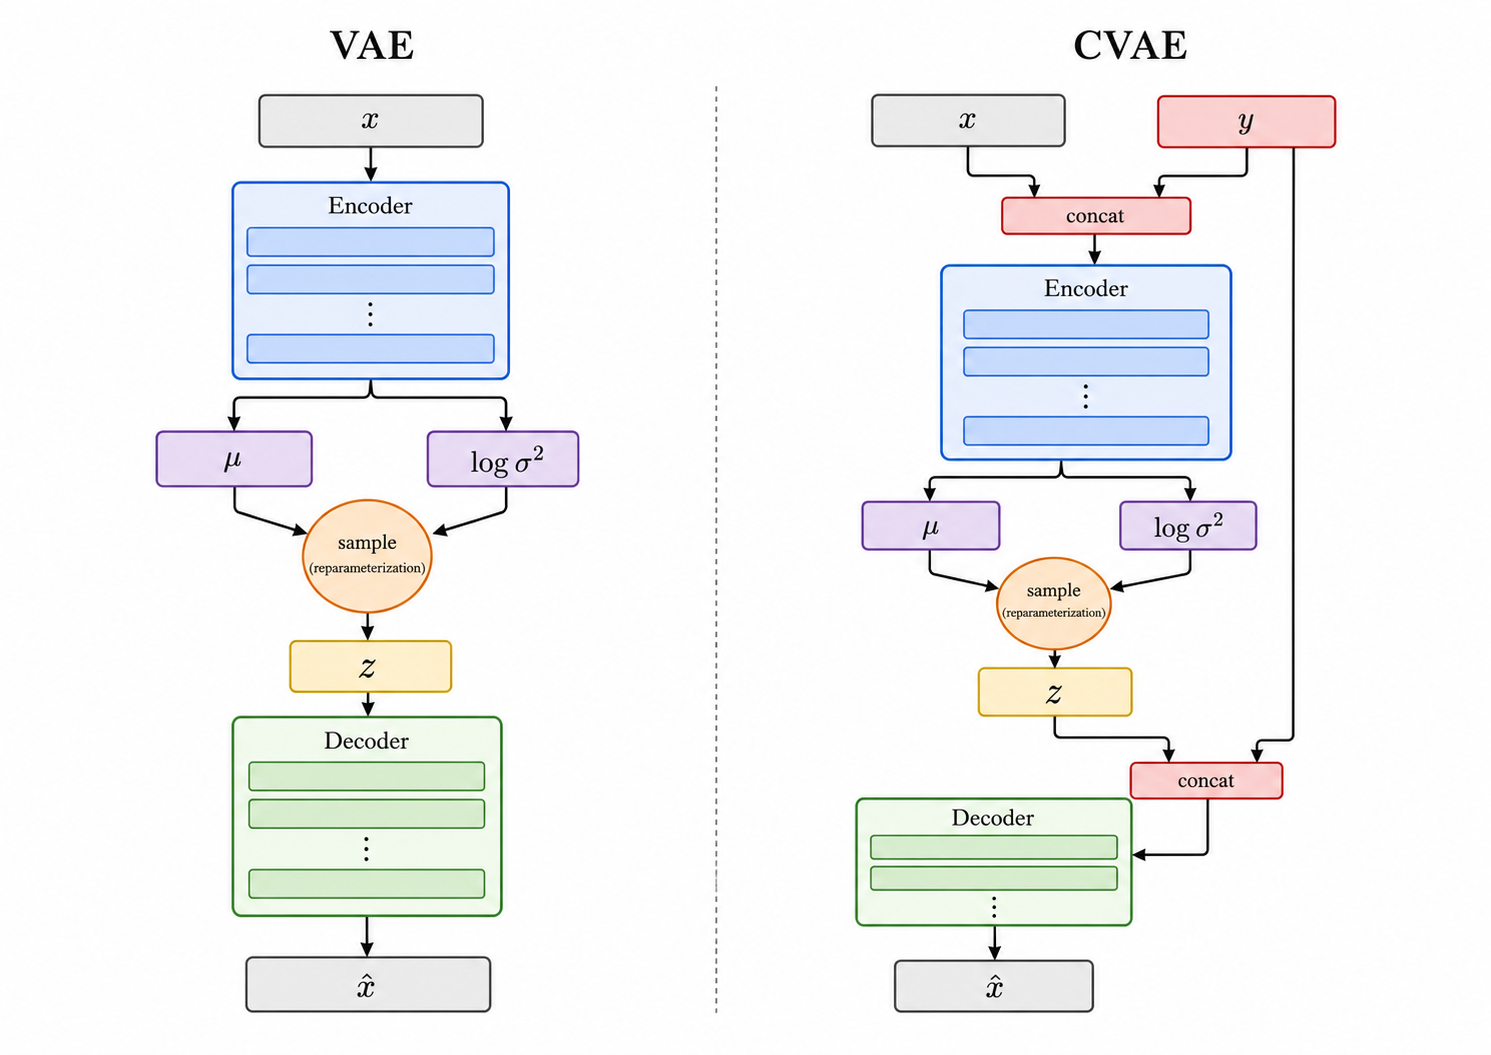

A Variational Autoencoder (VAE) is a generative model that learns to compress images into a compact latent representation and reconstruct them back, while also shaping that latent space to follow a known distribution (a standard normal) so new images can be generated by sampling from it directly. A Conditional VAE (CVAE) extends this by feeding the class label alongside the image into both the encoder and decoder, so the latent space captures shared visual variation across all classes while the label steers what specific class gets generated. This makes a CVAE well suited to this task: CIFAR10 requires generating images for 10 distinct classes on demand, which a CVAE handles directly through its label conditioning, rather than needing a separate model per class.


## 3. Preprocessing

CIFAR10 images are stored in a (32, 32, 3) shape, height, width, and 3 color channels (RGB). To prepare the data for training, we perform the following steps: normalize pixel values, encode labels, and split the data into train, validation, and test sets.


### 3.1 Normalize Pixel Values

We normalize pixel values by rescaling them from the 0-255 range to 0-1, so they are on a consistent scale suitable for our model.


In [ ]:
train_set = CIFAR10(root="..", train=True, download=True)
test_set = CIFAR10(root="..", train=False, download=True)
class_names = train_set.classes

# Channel-first (N, C, H, W) layout, expected by torch's Conv2d layers.
x_train = torch.tensor(train_set.data, dtype=torch.float32).permute(0, 3, 1, 2) / 255
x_test = torch.tensor(test_set.data, dtype=torch.float32).permute(0, 3, 1, 2) / 255
y_train = torch.tensor(train_set.targets, dtype=torch.long)
y_test = torch.tensor(test_set.targets, dtype=torch.long)

print("x_train:", x_train.shape, x_train.dtype, "range:", x_train.min().item(), "-", x_train.max().item())
print("x_test: ", x_test.shape, x_test.dtype)

### 3.2 Encode Labels

We encode labels (input) using one-hot encoding, transforming a categorical class value into a numerical vector that serves the same purpose as a conditioning signal for the encoder and decoder.


In [ ]:
num_classes = len(class_names)
y_train_onehot = F.one_hot(y_train, num_classes=num_classes).float()
y_test_onehot = F.one_hot(y_test, num_classes=num_classes).float()

print("y_train_onehot:", y_train_onehot.shape, y_train_onehot.dtype)

### 3.3 Train/Validation/Test Split

We split the data into train, validation, and test sets, so we can use some of the data to train the model and the rest to evaluate model performance. The official CIFAR10 test set (10,000 images) is kept fully held out, while the validation set is carved out of the 50,000 training images.


In [ ]:
val_size = 5000
generator = torch.Generator().manual_seed(42)
perm = torch.randperm(len(x_train), generator=generator)
val_idx, train_idx = perm[:val_size], perm[val_size:]

x_val, y_val, y_val_onehot = x_train[val_idx], y_train[val_idx], y_train_onehot[val_idx]
x_train, y_train, y_train_onehot = x_train[train_idx], y_train[train_idx], y_train_onehot[train_idx]

print("train:", x_train.shape)
print("val:  ", x_val.shape)
print("test: ", x_test.shape)

## 4. Sampling Layer (Reparameterization Trick)


### 4.1 The Reparameterization Trick

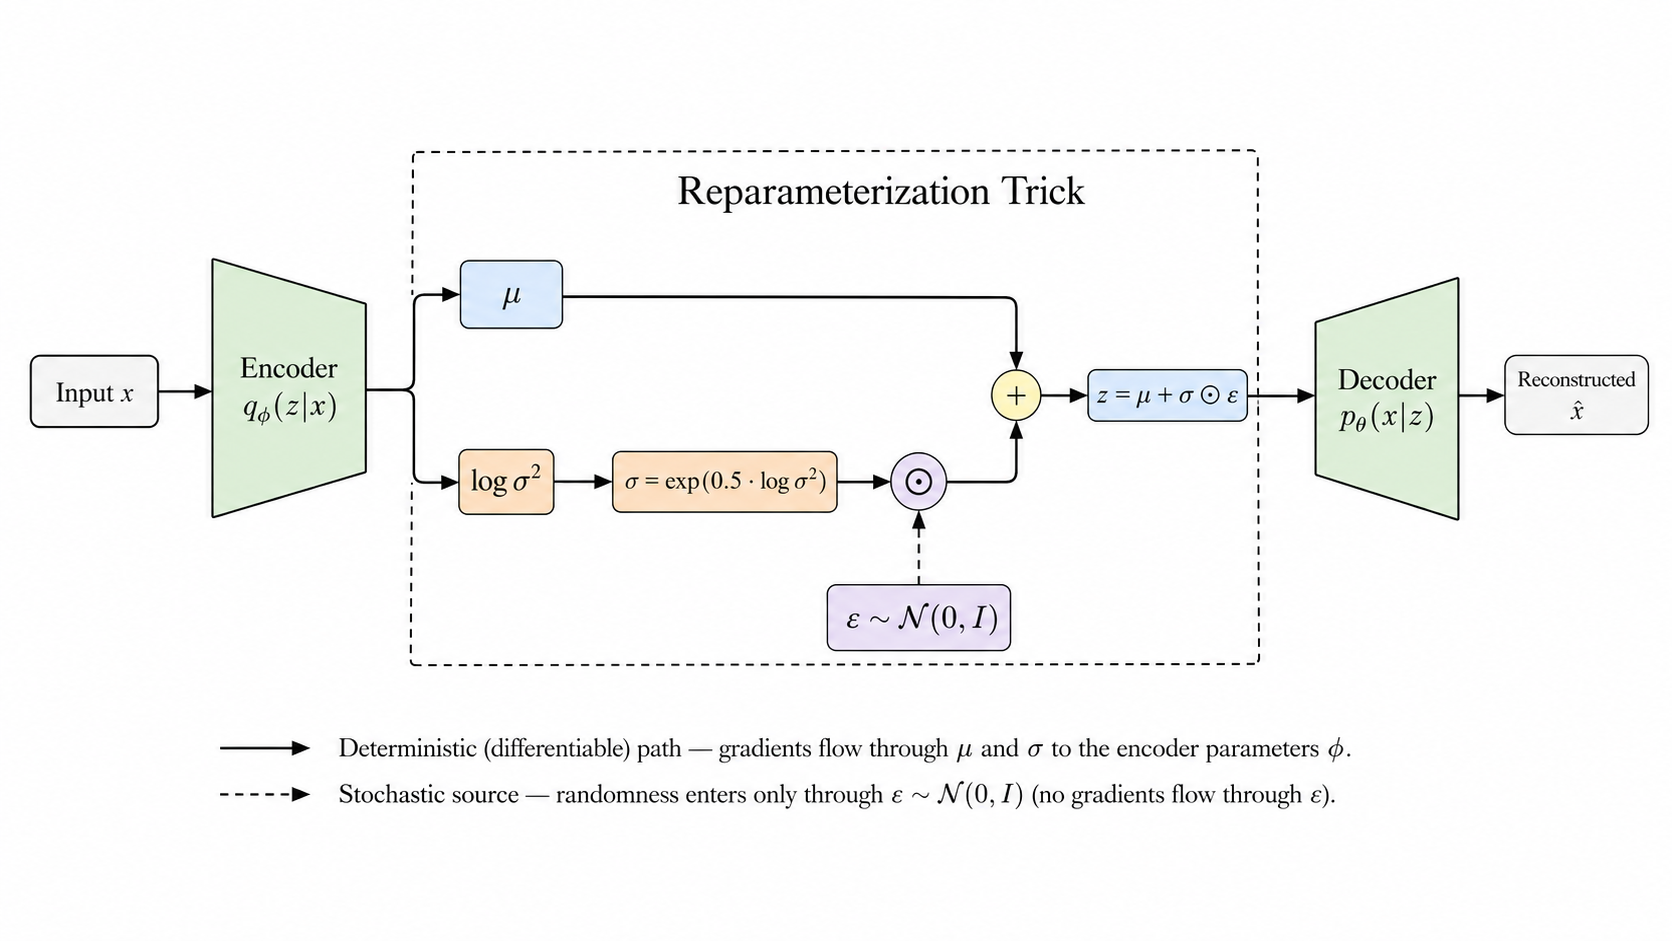

We use the reparameterization trick to move the source of randomness outside the network, rather than sampling directly from a distribution parameterized by the encoder's output. As shown above, the encoder $q_\phi(z|x)$ outputs $\mu$ and $\log \sigma^2$ for a given input, and $\sigma$ is computed from $\log \sigma^2$. Instead of sampling $z$ directly from $N(\mu, \sigma^2)$, we sample $\epsilon \sim N(0, I)$ separately and compute $z = \mu + \sigma \odot \epsilon$. The solid arrows mark the deterministic, differentiable path, gradients flow through $\mu$ and $\sigma$ back to the encoder parameters $\phi$, while the dashed arrow marks the only stochastic part, $\epsilon$, which needs no gradient. This keeps the entire encoder-to-decoder path differentiable, which sampling $z$ directly from $N(\mu, \sigma^2)$ would not allow (Gundersen, 2018).

### 4.2 Objective

We aim to produce a latent vector z that behaves like a genuine random sample from the distribution the encoder predicts for a given image, N(z_mean, z_var), while keeping the sampling step differentiable so gradients can still reach the encoder during training.


In [ ]:
class Sampling(nn.Module):
    """Reparameterization trick: z = z_mean + std * epsilon, epsilon ~ N(0, 1)."""

    def forward(self, z_mean, z_log_var):
        std = torch.exp(0.5 * z_log_var)
        epsilon = torch.randn_like(std)
        return z_mean + std * epsilon

### 4.3 Alternatives

There are other ways to handle this non-differentiability problem, depending on the type of latent variable involved:

-   **Gumbel-softmax**: used when the latent variable is discrete or categorical rather than continuous. It provides a continuous, differentiable relaxation of sampling from a categorical distribution, letting gradients flow even though the underlying variable is discrete.
-   **Vector quantization with a straight-through estimator (VQ-VAE)**: maps the encoder's output to the nearest vector in a learned discrete codebook, a step that has no gradient. A straight-through estimator works around this by copying gradients straight from the decoder's input back to the encoder's output during backpropagation, skipping over the non-differentiable lookup.
-   **Normalizing flows**: apply a sequence of invertible, differentiable transformations to a simple base distribution (e.g. a standard normal) to build a much richer, more expressive posterior, while still allowing exact density computation via the change-of-variables formula.

Standard Gaussian reparameterization is sufficient here since our latent space is continuous and CIFAR10 class-conditional generation does not require a highly complex posterior distribution.


## 5. Build the Conditional Encoder


### 5.1 What It Does

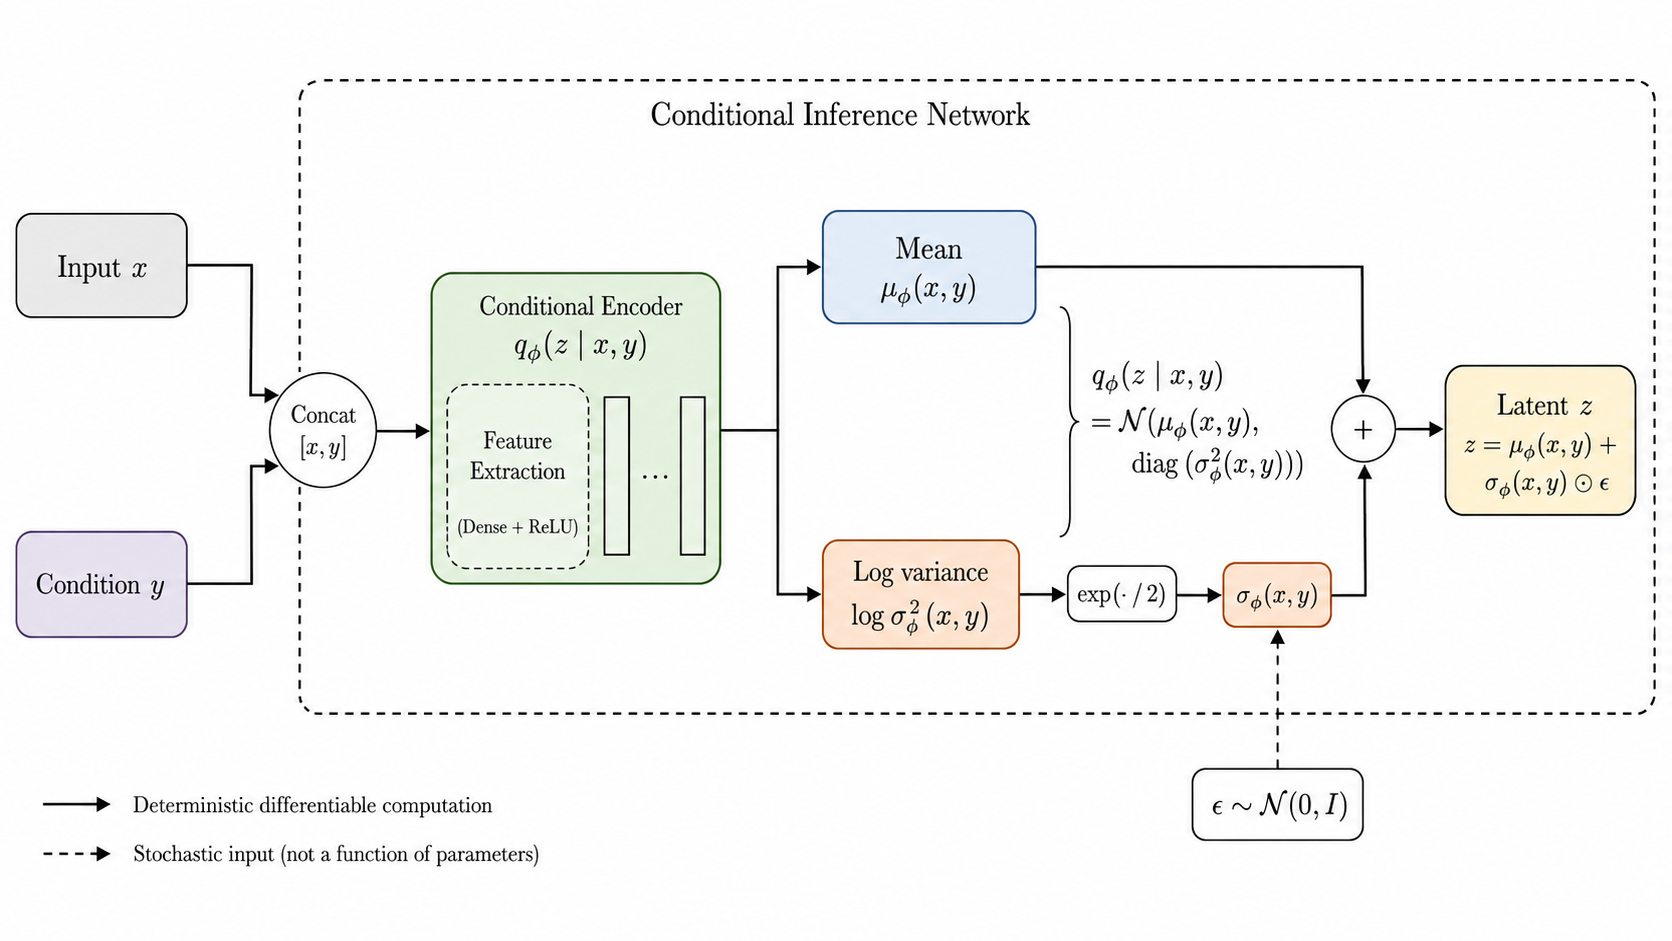

The conditional encoder $q_\phi(z|x,y)$ takes the input image $x$ and the one-hot condition $y$, concatenates them, and passes the result through a feature extraction stack (shown above as generic dense layers; in our implementation this is a stack of conv layers, since $x$ is a 32x32x3 image rather than a flat vector). The extracted features branch into two output heads, a mean $\mu_\phi(x,y)$ and a log variance $\log \sigma^2_\phi(x,y)$, which together define $q_\phi(z|x,y) = N(\mu_\phi(x,y), \text{diag}(\sigma^2_\phi(x,y)))$. These feed into the Sampling layer built in Section 4, which combines them with $\epsilon \sim N(0, I)$ to produce the latent $z = \mu_\phi(x,y) + \sigma_\phi(x,y) \odot \epsilon$.

In [ ]:
latent_dim = 128

class Encoder(nn.Module):
    def __init__(self, num_classes, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3 + num_classes, 32, kernel_size=3, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 16x16 -> 8x8
            nn.ReLU(),
        )
        self.fc_mean = nn.Linear(64 * 8 * 8, latent_dim)
        self.fc_log_var = nn.Linear(64 * 8 * 8, latent_dim)
        self.sampling = Sampling()

    def forward(self, x, y):
        # Broadcast the one-hot label into a spatial map and concatenate it as extra channels.
        y_map = y.view(y.size(0), -1, 1, 1).expand(-1, -1, x.size(2), x.size(3))
        x = torch.cat([x, y_map], dim=1)

        features = self.conv(x).flatten(start_dim=1)
        z_mean = self.fc_mean(features)
        z_log_var = self.fc_log_var(features)
        z = self.sampling(z_mean, z_log_var)
        return z_mean, z_log_var, z

encoder = Encoder(num_classes, latent_dim)
print(encoder)

In [ ]:
# Build the encoder: conv layers on the image input, label input concatenated in, output z_mean/z_log_var/z.

## 6. Build the Conditional Decoder


### 6.1 What It Does

One sentence explaining that the latent vector and one-hot label are concatenated, dense-expanded, and upsampled via transposed convs back into a 32x32x3 image — followed by a diagram of this layer flow.


In [ ]:
# Diagram: decoder layer flow — z + label -> concat -> dense expand -> reshape -> transposed conv stack -> reconstructed image.

### 6.2 Implementation


In [ ]:
# Build the decoder: concatenate latent vector with label, dense-expand, then transposed convs back to 32x32x3.

## 7. Define the CVAE Training Step


### 7.1 Loss Formulation

One sentence explaining the total loss is reconstruction loss (how close the output is to the input) plus a KL-weighted divergence term (how close the latent distribution is to a standard normal), and why both are needed together.


### 7.2 Architecture Pseudocode

```
train_step(images, labels):
    with gradient_tape:
        z_mean, z_log_var, z = encoder(images, labels)
        reconstruction = decoder(z, labels)

        reconstruction_loss = binary_crossentropy(images, reconstruction), summed over pixels, averaged over batch
        kl_loss = -0.5 * sum(1 + z_log_var - z_mean^2 - exp(z_log_var)), averaged over batch
        total_loss = reconstruction_loss + kl_weight * kl_loss

    gradients = gradient_tape.gradient(total_loss, encoder.weights + decoder.weights)
    optimizer.apply_gradients(gradients)

    return total_loss, reconstruction_loss, kl_loss
```


### 7.3 Implementation


In [ ]:
# Define the CVAE keras.Model subclass with reconstruction + KL loss tracked as metrics.

## 8. Train the Model


### 8.1 Fit and Save Best Weights


In [ ]:
# Compile and fit the CVAE, saving the best weights to a .h5 checkpoint via ModelCheckpoint.

### 8.2 Loss Curves


In [ ]:
# Plot training/validation loss curves (total, reconstruction, KL).

### Notes

One sentence noting whether training and validation loss curves track closely together or diverge, and what that implies about overfitting at this baseline capacity.


### 8.3 Reconstruction Sanity Check

One sentence noting we're encoding real validation images and decoding them back to confirm the model can at least reconstruct what it has seen, reporting validation reconstruction error (MSE) as a concrete number.


In [ ]:
# Encode a sample of validation images, decode back, show original vs reconstruction side by side, and print MSE.

### Notes

One sentence naming the printed MSE value and stating whether reconstructions look sharp or blurry relative to that number.


### 8.4 Per-Class Reconstruction Error

One sentence noting we're breaking down validation reconstruction error by class, giving quantitative evidence for which classes are harder for the model to represent.


In [ ]:
# Compute mean per-image reconstruction error grouped by class, bar chart the result.

### Notes

One sentence naming the classes with highest and lowest reconstruction error and whether that ranking matches the EDA's per-class variance findings.


### Notes

One sentence noting whether classes form visually distinct clusters in the PCA scatter or overlap heavily, and what that implies about how separable classes are in latent space.


## 9. Latent Space Visualization


### 9.1 PCA Scatter by Class


In [ ]:
# Project latent means to 2D via PCA and scatter-plot colored by class.

### 9.2 Latent Interpolation

One sentence noting we're decoding a smooth path between two latent points (or two classes) to show the latent space is continuous, not just memorized.


In [ ]:
# Interpolate between two latent vectors (or classes) and decode each step to a grid of images.

### Notes

One sentence noting whether the interpolation grid shows a smooth visual transition or an abrupt jump partway through, and what that implies about the latent space's continuity.


### 9.3 Per-Dimension Effect Grid

One sentence noting we're varying one latent dimension at a time (others fixed) to see what visual feature each dimension controls.


In [ ]:
# Fix all latent dims at 0 except one, sweep that dim across a range, decode and display the resulting image grid.

### Notes

One sentence naming which visual feature (if any) the swept latent dimension appears to control, or noting if no dimension shows an interpretable single effect.


### 9.4 Aggregate Posterior Check

One sentence noting we're overlaying a histogram of the encoder's z_mean/z_var outputs across the validation set against the standard normal prior, to verify the KL term is actually pulling the latent distribution toward N(0,1).


In [ ]:
# Encode the validation set, histogram z_mean and z_var across all dims, overlay against the standard normal prior.

### Notes

One sentence noting whether the encoder's z_mean/z_var histograms line up closely with the standard normal prior or diverge, and what that implies about how well the KL term is regularizing the latent space.


### 9.5 Class Centroid Distance Heatmap

One sentence noting we're computing each class's mean latent vector and the pairwise distances between them, to quantify which classes sit closest together in latent space instead of just eyeballing the PCA scatter.


In [ ]:
# Compute per-class mean latent vector, pairwise distance matrix between all 10, display as a heatmap.

### Notes

One sentence naming the closest and farthest class pairs in the heatmap and whether that matches an intuitive visual/semantic similarity (e.g. cat/dog close, truck/bird far).


## 10. Generate 1000 Class-Conditioned Images


### 10.1 Sample and Decode

One sentence noting generation samples fresh z vectors from the standard normal prior (not from encoding real images) and pairs them with a chosen class label, decoding through the decoder only.


In [ ]:
# Sample random z vectors, decode with each of the 10 class labels to generate 100 images per class (1000 total).

### 10.2 Save to Disk

One sentence noting all 1000 images are written to disk organized by class folder, as required for submission.


In [ ]:
# Save the generated images to disk as required for submission.

### 10.3 Preview Grid

One sentence noting we're displaying a small sample (a few per class) inline for a visual sanity check, separate from the full 1000 saved to disk.


In [ ]:
# Display a grid of sample generated images, a few per class, for visual inspection.

## 11. Evaluate Generated Image Quality


### 11.1 Eye-Test Scoring

One sentence noting we're manually scoring a sample of the saved generated images (e.g. 10 per class) as clear/marginal/nonsense — this is the primary metric used across every notebook; FID is added separately in Section 11.5 as a quantitative complement, not a replacement.


In [ ]:
# Manually score a sample of generated images per class as clear / marginal / nonsense, tally results.

### 11.2 Per-Class Score Summary

One sentence noting we're tallying the eye-test scores by class into a bar chart, giving the evidence base for the discussion below and a point of comparison against the EDA's per-class variance/mean-image findings.


In [ ]:
# Tally clear/marginal/nonsense counts per class, bar chart the result.

### 11.3 Discussion: Class Difficulty

One sentence noting which classes scored best/worst on the eye-test (Section 11.2) and connecting that to the EDA's per-class variance/mean-image findings — e.g. visually uniform classes (low variance, distinctive mean image) should generate more reliably than visually diverse ones.


### 11.4 Discussion: Color vs. Black-and-White (Prediction)

One sentence giving a reasoned prediction only (no grayscale model trained here) on whether black-and-white generation would be easier or harder than color, based on the EDA's per-channel/color-signature findings — this prediction is tested empirically in `vae_improvement.ipynb` Section 7 (Experiment 4: Color vs. Grayscale), which is the notebook to cite for the actual answer.


### 11.5 FID Score

One sentence noting we're computing Fréchet Inception Distance between real validation images and the 1000 generated images using a frozen pretrained InceptionV3 as a fixed feature extractor (not fine-tuned), giving a quantitative complement to the eye-test that isn't self-graded.


In [ ]:
# Load InceptionV3 (imagenet weights, no top, pooling='avg') as a frozen feature extractor, resize images to 299x299 as required.

In [ ]:
# Extract InceptionV3 features for a sample of real validation images and for the 1000 generated images.

In [ ]:
# Fit a Gaussian (mean, covariance) to each feature set, compute Frechet distance between them, print the FID score.

### Notes

One sentence naming the printed FID score and stating whether it's low/high relative to typical FID ranges for small 32x32 image generation.


## 12. Baseline Conclusion

One sentence summarizing baseline model performance and key takeaways, plus saving the baseline weights/metrics to disk so `improvements_vae.ipynb` can load them without retraining.


In [ ]:
# Save baseline config, final losses, eye-test scores, and FID score to a small JSON file for improvements_vae.ipynb to load.